In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv('BostonHousing.csv')
df.shape

(506, 14)

In [7]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [14]:
x=df['RM']
y=df['MEDV']

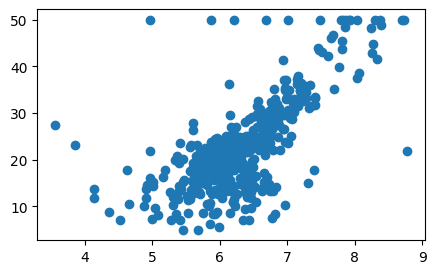

In [15]:
plt.figure(figsize=(5,3)) #size in inches
plt.scatter(x,y)
plt.show()

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [20]:
x=np.reshape(x,(-1,1))
y=np.reshape(y,(-1,1))
n=len(x)
# scaling the data between 0-1 
minmax=MinMaxScaler()
# fit transform takes 2-D input
scaled_x = minmax.fit_transform(x)
scaled_y = minmax.fit_transform(y)

In [21]:
def gradient_descent(epochs,alpha):
    slope,inter=  0,0
    for i in range(epochs):
        y_pred = scaled_x * slope + inter
        loss = y_pred-scaled_y
        gradSlope = (2/n) * np.dot(loss.T,scaled_x)
        gradInter = (2/n) * np.sum(loss)
        slope = slope - gradSlope * alpha
        inter = inter - gradInter * alpha
    return slope,inter

In [22]:
epochs=1000 # no of iterations
alpha=0.1   # learning rate
slope,inter=gradient_descent(epochs,alpha)
print("Slope: ",slope,"Inter: ",inter)

Slope:  [[1.00349879]] Inter:  -0.13368578499266606


In [23]:
y_pred=[]
for i in range(n):
    pred = slope[0][0] * scaled_x[i] + inter
    y_pred.append(pred)

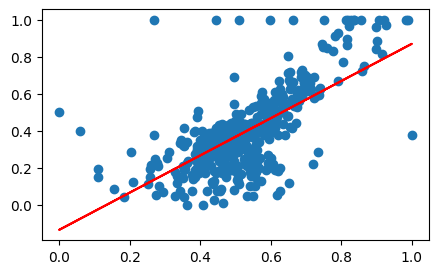

In [24]:
plt.figure(figsize=(5,3)) #size in inches
plt.scatter(scaled_x,scaled_y)
plt.plot(scaled_x,y_pred,color='red')
plt.show()